### Pandas (GroupBy, Sort, Aggregation, Pivot, Apply) and Regex Basics

In [1]:
# Import Required Libraries
import pandas as pd

### 1. Grouping Data (groupby)
# Concept: Group data based on one or more columns and perform aggregate operations.

| City         | Sales | Year |
|--------------|-------|------|
| New York     | 200   | 2020 |
| Los Angeles  | 150   | 2020 |
| Chicago      | 300   | 2020 |
| New York     | 220   | 2021 |
| Los Angeles  | 180   | 2021 |
------------------------------------------------------

| City         | Total Sales |
|--------------|-------------|
| New York     | 420         |
| Los Angeles  | 330         |
| Chicago      | 300         |


In [6]:
# Example Dataset
data = {'City': ['New York', 'Los Angeles', 'Chicago', 'New York', 'Los Angeles'],
        'Sales': [200, 150, 300, 220, 180],
        'Year': [2020, 2020, 2020, 2021, 2021]}

In [7]:
# Example 1: Group by City and calculate total sales
df = pd.DataFrame(data)
df

grouped_city = df.groupby('City')['Sales'].sum() # grouped by City and summing slaes column

result = grouped_city.reset_index() # reset index to 

result.columns = ['City', 'Total Sales'] # updating columb name from 'Sales' to 'Total Sales'

result

,City,Total Sales
0,Chicago,300
1,Los Angeles,330
2,New York,420


In [4]:
df

,City,Sales,Year
0,New York,200,2020
1,Los Angeles,150,2020
2,Chicago,300,2020
3,New York,220,2021
4,Los Angeles,180,2021


In [5]:
# Example 2: Group by Year and find average sales

grouped = df.groupby( 'Year')['Sales'].mean().astype(int).reset_index()

grouped.columns = ['Year', 'Average sales']

grouped

,Year,Average sales
0,2020,216
1,2021,200


In [6]:
# Scenario-Based Questions:
# 1. Group data by both City and Year, then find the maximum sales.

max_sale = df.groupby(['City', 'Year'])['Sales'].max().reset_index()

max_sale

,City,Year,Sales
0,Chicago,2020,300
1,Los Angeles,2020,150
2,Los Angeles,2021,180
3,New York,2020,200
4,New York,2021,220


In [7]:
# 2. Find the total sales for each city.
# Group the data by Year and calculate the total number of sales records (count) for each year.

count = df.groupby('Year')['Sales'].count().reset_index()
count.columns = ['Year', 'Count of Sale']
count

,Year,Count of Sale
0,2020,3
1,2021,2


In [8]:
df.groupby('City')['Sales'].sum().reset_index()

,City,Sales
0,Chicago,300
1,Los Angeles,330
2,New York,420


In [9]:
# City with maximum sale in column wise

df.groupby('City')['Sales'].sum().reset_index().max().to_frame().T


,City,Sales
0,New York,420


In [10]:
type(df.groupby('City')['Sales'].sum().reset_index().max()) # why this is a series

pandas.core.series.Series

### 2. Sorting Data
# Concept: Sorting using `sort_values` or `sort_index`.

In [11]:
# Example 1: Sort by Sales (Descending)
df_sort = df.sort_values(by = 'Sales', ascending = False).reset_index(drop=True)
df_sort

#reset index will add anotheer column as starting from 0 in a sequence, while also having the previous index column,  now inorder to remove the previous index column we do "drop = True"..which means we are agreeing to remove that column

,City,Sales,Year
0,Chicago,300,2020
1,New York,220,2021
2,New York,200,2020
3,Los Angeles,180,2021
4,Los Angeles,150,2020


In [12]:
# Example 2: Sort by Year and then by Sales (Ascending)
df_sort = df.sort_values(by = ['Year','Sales'])
df_sort

,City,Sales,Year
1,Los Angeles,150,2020
0,New York,200,2020
2,Chicago,300,2020
4,Los Angeles,180,2021
3,New York,220,2021


In [13]:
# Scenario-Based Questions:
# 1. Sort the data by City alphabetically.
df.sort_values('City')

,City,Sales,Year
2,Chicago,300,2020
1,Los Angeles,150,2020
4,Los Angeles,180,2021
0,New York,200,2020
3,New York,220,2021


In [14]:
data = {'City': ['New York', 'Los Angeles', 'Chicago', None, 'Los Angeles'],
        'Sales': [200, 150, 300, 220, None],
        'Year': [2020, 2020, 2020, 2021, None]}
df1 = pd.DataFrame(data)
df1

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,City,Sales,Year
0,New York,200.0,2020.0
1,Los Angeles,150.0,2020.0
2,Chicago,300.0,2020.0
3,None,220.0,2021.0
4,Los Angeles,NaN,NaN


In [15]:
# 2. Sort by Year and ensure missing values appear first.
df1.sort_values(by = 'Year', na_position = 'first').reset_index(drop = True)

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,City,Sales,Year
0,Los Angeles,NaN,NaN
1,New York,200.0,2020.0
2,Los Angeles,150.0,2020.0
3,Chicago,300.0,2020.0
4,None,220.0,2021.0


In [16]:
df_sorting_index = df.sort_index(axis=0, ascending = False)

df_sorting_index

,City,Sales,Year
4,Los Angeles,180,2021
3,New York,220,2021
2,Chicago,300,2020
1,Los Angeles,150,2020
0,New York,200,2020


### 3. Aggregation
# Concept: Aggregate using functions like `sum`, `mean`, or custom functions.

In [17]:
# Example: Aggregate total Sales and latest Year by City
#df.groupby(['City', 'Year'])['Sales'].sum().reset_index().sort_values('Year', ascending=False)
agg_df = df.groupby('City').agg({'Sales':sum, 'Year':max}).reset_index()
agg_df

<ipython-input-17-1965da9fb4b3>:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  agg_df = df.groupby('City').agg({'Sales':sum, 'Year':max}).reset_index()
<ipython-input-17-1965da9fb4b3>:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  agg_df = df.groupby('City').agg({'Sales':sum, 'Year':max}).reset_index()


,City,Sales,Year
0,Chicago,300,2020
1,Los Angeles,330,2021
2,New York,420,2021


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   City    5 non-null      object
 1   Sales   5 non-null      int64 
 2   Year    5 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 248.0+ bytes


In [19]:
df.describe()

,Sales,Year
count,5.000000,5.000000
mean,210.000000,2020.400000
std,56.568542,0.547723
min,150.000000,2020.000000
25%,180.000000,2020.000000
50%,200.000000,2020.000000
75%,220.000000,2021.000000
max,300.000000,2021.000000


In [20]:
# Scenario-Based Questions:
# 1. Group by Year and find both total and average Sales.

# method 1

ag_df = df.groupby('Year')['Sales'].agg(['sum', 'mean']).astype(int).reset_index()

ag_df.columns = ['Year', 'Total Sale', 'Average']

ag_df

,Year,Total Sale,Average
0,2020,650,216
1,2021,400,200


In [21]:
# method 2
df3 = df.groupby('Year').agg({'Sales': ['sum', 'mean']}).reset_index()
df3

Year Sales            
          sum        mean
0  2020   650  216.666667
1  2021   400  200.000000

In [22]:
# method 3
df.groupby('Year').agg(total_sales = ('Sales', 'sum'), Average_sales = ('Sales', 'mean')).reset_index()

,Year,total_sales,Average_sales
0,2020,650,216.666667
1,2021,400,200.000000


In [23]:
# 2. Apply multiple functions like min and max on the Sales column.
df.groupby('Year')['Sales'].agg(['min', 'max', 'mean', 'sum']).reset_index().astype(int)

,Year,min,max,mean,sum
0,2020,150,300,216,650
1,2021,180,220,200,400


In [24]:
df.groupby('Year').agg(total_sales = ('Sales', 'sum'), Average_sales = ('Sales', 'mean'), Min = ('Sales', 'min'), Max = ('Sales', 'max') ).reset_index().astype(int)

,Year,total_sales,Average_sales,Min,Max
0,2020,650,216,150,300
1,2021,400,200,180,220


In [25]:
# Pivot
# Apply

df.groupby('City').nunique()

df['City'].nunique()

3

In [115]:
data = {
    'Claim_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Patient_ID': [1, 2, 3, 1, 4, 2, 5, 6, 7, 8],
    'Provider_ID': [501, 502, 503, 501, 504, 502, 505, 506, 507, 508],
    'Procedure_Code': ['A123', 'B234', 'A123', 'C345', 'D456', 'B234', 'C345', 'D456', 'A123', 'B234'],
    'Billed_Amount': [500, 700, 500, 1200, 1500, 700, 1200, 1500, 500, 700],
    'Paid_Amount': [450, 650, 500, 1000, 1400, 600, 1100, 1400, 400, 650],
    'Claim_Date': pd.to_datetime([
        '2024-01-01', '2024-01-03', '2024-01-07', '2024-01-10', '2024-01-15',
        '2024-02-01', '2024-02-03', '2024-02-07', '2024-02-10', '2024-02-15'
    ]),
    'Status': ['Approved', 'Denied', 'Approved', 'Approved', 'Pending', 'Denied', 'Approved', 'Pending', 'Approved', 'Denied'],
    'Fraud_Flag': [0, 1, 0, 0, 0, 1, 0, 0, 0, 1],  # 1 = Potential fraud, 0 = Normal claim
}


# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Print the DataFrame
print(df)

   Claim_ID  Patient_ID  Provider_ID Procedure_Code  Billed_Amount  \
0       101           1          501           A123            500   
1       102           2          502           B234            700   
2       103           3          503           A123            500   
3       104           1          501           C345           1200   
4       105           4          504           D456           1500   
5       106           2          502           B234            700   
6       107           5          505           C345           1200   
7       108           6          506           D456           1500   
8       109           7          507           A123            500   
9       110           8          508           B234            700   

   Paid_Amount Claim_Date    Status  Fraud_Flag  
0          450 2024-01-01  Approved           0  
1          650 2024-01-03    Denied           1  
2          500 2024-01-07  Approved           0  
3         1000 2024-01-10  Ap

In [27]:
# Display the first 5 rows of a DataFrame.

df.head()

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag
0,101,1,501,A123,500,450,2024-01-01,Approved,0
1,102,2,502,B234,700,650,2024-01-03,Denied,1
2,103,3,503,A123,500,500,2024-01-07,Approved,0
3,104,1,501,C345,1200,1000,2024-01-10,Approved,0
4,105,4,504,D456,1500,1400,2024-01-15,Pending,0


In [28]:
# Retrieve a single column as a Series.

print(df['Claim_ID'])

type(df['Claim_ID'])

0    101
1    102
2    103
3    104
4    105
5    106
6    107
7    108
8    109
9    110
Name: Claim_ID, dtype: int64


pandas.core.series.Series

In [29]:
# Find the number of missing values in each column.

df.isnull().sum()

Claim_ID          0
Patient_ID        0
Provider_ID       0
Procedure_Code    0
Billed_Amount     0
Paid_Amount       0
Claim_Date        0
Status            0
Fraud_Flag        0
dtype: int64

In [30]:
# Sort the DataFrame by a specific column.

df.sort_values(by='Status')[['Claim_ID', 'Status']].head()

,Claim_ID,Status
0,101,Approved
2,103,Approved
3,104,Approved
6,107,Approved
8,109,Approved


In [31]:
# Select rows where a column’s value is greater than 50.
df[df['Patient_ID']>10]

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag


In [32]:
# Rename a column.

df.rename(columns = {'Fraud_Flag':'Is_fraud'}, inplace=True)

df

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Is_fraud
0,101,1,501,A123,500,450,2024-01-01,Approved,0
1,102,2,502,B234,700,650,2024-01-03,Denied,1
2,103,3,503,A123,500,500,2024-01-07,Approved,0
3,104,1,501,C345,1200,1000,2024-01-10,Approved,0
4,105,4,504,D456,1500,1400,2024-01-15,Pending,0
5,106,2,502,B234,700,600,2024-02-01,Denied,1
6,107,5,505,C345,1200,1100,2024-02-03,Approved,0
7,108,6,506,D456,1500,1400,2024-02-07,Pending,0
8,109,7,507,A123,500,400,2024-02-10,Approved,0
9,110,8,508,B234,700,650,2024-02-15,Denied,1


In [33]:
# Drop a column from the DataFrame.

df.drop(columns = 'Paid_Amount', inplace=True)


In [34]:
df

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Claim_Date,Status,Is_fraud
0,101,1,501,A123,500,2024-01-01,Approved,0
1,102,2,502,B234,700,2024-01-03,Denied,1
2,103,3,503,A123,500,2024-01-07,Approved,0
3,104,1,501,C345,1200,2024-01-10,Approved,0
4,105,4,504,D456,1500,2024-01-15,Pending,0
5,106,2,502,B234,700,2024-02-01,Denied,1
6,107,5,505,C345,1200,2024-02-03,Approved,0
7,108,6,506,D456,1500,2024-02-07,Pending,0
8,109,7,507,A123,500,2024-02-10,Approved,0
9,110,8,508,B234,700,2024-02-15,Denied,1


In [35]:
# Fill missing values with the mean.

df.fillna(df['Billed_Amount'].mean(), inplace=True)

In [36]:
# Add a new column to the DataFrame
df['New_column'] = 0

In [37]:
# Select a subset of rows and columns using loc and iloc.

df.loc(1:, :1)

SyntaxError: invalid syntax (<ipython-input-37-97a980a401f9>, line 3)

In [45]:
# Select a subset of rows and columns using loc and iloc.
print(df.loc[1,]) # printing 1 row all column
print()
print(df.iloc[1:2,:]) # printing 1 row all columns

Claim_ID                          102
Patient_ID                          2
Provider_ID                       502
Procedure_Code                   B234
Billed_Amount                     700
Claim_Date        2024-01-03 00:00:00
Status                         Denied
Is_fraud                            1
New_column                          0
Name: 1, dtype: object

   Claim_ID  Patient_ID  Provider_ID Procedure_Code  Billed_Amount Claim_Date  \
1       102           2          502           B234            700 2024-01-03   

   Status  Is_fraud  New_column  
1  Denied         1           0  


In [47]:
# Convert a column to a different data type.
df['Provider_ID'].astype(float)


0    501.0
1    502.0
2    503.0
3    501.0
4    504.0
5    502.0
6    505.0
7    506.0
8    507.0
9    508.0
Name: Provider_ID, dtype: float64

In [59]:
# Find the average of all numerical columns.
df.mean(numeric_only=True)

Claim_ID         105.5
Patient_ID         3.9
Provider_ID      503.9
Billed_Amount    900.0
Paid_Amount      815.0
Fraud_Flag         0.3
dtype: float64

In [67]:
# Count the number of unique values in a column.

df['Provider_ID'].nunique()

8

In [71]:
# Use groupby() to find the mean of a column by category.
df.groupby('Status')['Billed_Amount'].mean()


Status
Approved     780.0
Denied       700.0
Pending     1500.0
Name: Billed_Amount, dtype: float64

In [72]:
data2 = {
    'Claim_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Patient_ID': [1, 2, 3, 1, 4, 2, 5, 6, 7, 8],
    'Provider_ID': [501, 502, 503, 501, 504, 502, 505, 506, 507, 508],
    'Procedure_Code': ['A123', 'B234', 'A123', 'C345', 'D456', 'B234', 'C345', 'D456', 'A123', 'B234'],
    'Billed_Amount': [500, 700, 500, 1200, 1500, 700, 1200, 1500, 500, 700],
    'Paid_Amount': [450, 650, 500, 1000, 1400, 600, 1100, 1400, 400, 650],
    'Claim_Date': pd.to_datetime([
        '2024-01-01', '2024-01-03', '2024-01-07', '2024-01-10', '2024-01-15',
        '2024-02-01', '2024-02-03', '2024-02-07', '2024-02-10', '2024-02-15'
    ]),
    'Status': ['Approved', 'Denied', 'Approved', 'Approved', 'Pending', 'Denied', 'Approved', 'Pending', 'Approved', 'Denied'],
    'Fraud_Flag': [0, 1, 0, 0, 0, 1, 0, 0, 0, 1],  # 1 = Potential fraud, 0 = Normal claim
}

df2 = pd.DataFrame(data2)

In [76]:
# Merge two DataFrames using merge().

df.merge(df2, on = 'Claim_ID')

,Claim_ID,Patient_ID_x,Provider_ID_x,Procedure_Code_x,Billed_Amount_x,Paid_Amount_x,Claim_Date_x,Status_x,Fraud_Flag_x,Patient_ID_y,Provider_ID_y,Procedure_Code_y,Billed_Amount_y,Paid_Amount_y,Claim_Date_y,Status_y,Fraud_Flag_y
0,101,1,501,A123,500,450,2024-01-01,Approved,0,1,501,A123,500,450,2024-01-01,Approved,0
1,102,2,502,B234,700,650,2024-01-03,Denied,1,2,502,B234,700,650,2024-01-03,Denied,1
2,103,3,503,A123,500,500,2024-01-07,Approved,0,3,503,A123,500,500,2024-01-07,Approved,0
3,104,1,501,C345,1200,1000,2024-01-10,Approved,0,1,501,C345,1200,1000,2024-01-10,Approved,0
4,105,4,504,D456,1500,1400,2024-01-15,Pending,0,4,504,D456,1500,1400,2024-01-15,Pending,0
5,106,2,502,B234,700,600,2024-02-01,Denied,1,2,502,B234,700,600,2024-02-01,Denied,1
6,107,5,505,C345,1200,1100,2024-02-03,Approved,0,5,505,C345,1200,1100,2024-02-03,Approved,0
7,108,6,506,D456,1500,1400,2024-02-07,Pending,0,6,506,D456,1500,1400,2024-02-07,Pending,0
8,109,7,507,A123,500,400,2024-02-10,Approved,0,7,507,A123,500,400,2024-02-10,Approved,0
9,110,8,508,B234,700,650,2024-02-15,Denied,1,8,508,B234,700,650,2024-02-15,Denied,1


In [79]:
# Find the most frequent value in a column.

df['Provider_ID'].mode()

0    501
1    502
Name: Provider_ID, dtype: int64

In [84]:
# Compute cumulative sum of a column.

df['Billed_Amount'].sum()

9000

In [91]:
# Apply a custom function to transform a column.

df['Paid_Amount'] = df['Paid_Amount'].apply(lambda x : x**2 )

In [95]:
df.head()

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag
0,101,1,501,A123,500,202500,2024-01-01,Approved,0
1,102,2,502,B234,700,422500,2024-01-03,Denied,1
2,103,3,503,A123,500,250000,2024-01-07,Approved,0
3,104,1,501,C345,1200,1000000,2024-01-10,Approved,0
4,105,4,504,D456,1500,1960000,2024-01-15,Pending,0


In [103]:
# Use pivot_table() to summarize data.

pd.pivot_table(df,  index=['Provider_ID'], values= ['Billed_Amount','Paid_Amount'],columns=['Status'], aggfunc="sum",fill_value=0)

Billed_Amount                Paid_Amount                 
Status           Approved Denied Pending    Approved  Denied  Pending
Provider_ID                                                          
501                  1700      0       0     1202500       0        0
502                     0   1400       0           0  782500        0
503                   500      0       0      250000       0        0
504                     0      0    1500           0       0  1960000
505                  1200      0       0     1210000       0        0
506                     0      0    1500           0       0  1960000
507                   500      0       0      160000       0        0
508                     0    700       0           0  422500        0

In [113]:
# Reshape a DataFrame using melt().

df.melt(id_vars=['Claim_ID'], value_vars=['column_to_unpivot'])

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['column_to_unpivot']"

In [121]:
# Use applymap() to apply a function to every element in the DataFrame.

df.applymap(lambda x : x + 1 if isinstance(x, (int, float)) else x)

<ipython-input-121-d4ed60b90116>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(lambda x : x + 1 if isinstance(x, (int, float)) else x)


,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag
0,102,2,502,A123,501,451,2024-01-01,Approved,1
1,103,3,503,B234,701,651,2024-01-03,Denied,2
2,104,4,504,A123,501,501,2024-01-07,Approved,1
3,105,2,502,C345,1201,1001,2024-01-10,Approved,1
4,106,5,505,D456,1501,1401,2024-01-15,Pending,1
5,107,3,503,B234,701,601,2024-02-01,Denied,2
6,108,6,506,C345,1201,1101,2024-02-03,Approved,1
7,109,7,507,D456,1501,1401,2024-02-07,Pending,1
8,110,8,508,A123,501,401,2024-02-10,Approved,1
9,111,9,509,B234,701,651,2024-02-15,Denied,2


In [123]:
# Use map() to apply a function to a Series.

df['Billed_Amount'].map(lambda x : x*2)

0    1000
1    1400
2    1000
3    2400
4    3000
5    1400
6    2400
7    3000
8    1000
9    1400
Name: Billed_Amount, dtype: int64

<Axes: title={'center': 'Age vs. Claim Amount'}, xlabel='Provider_ID', ylabel='Billed_Amount'>

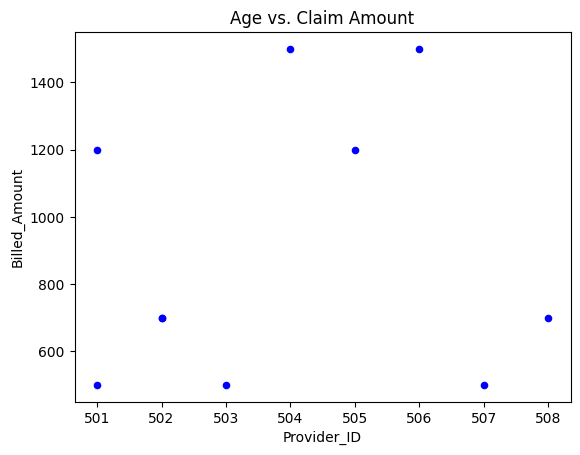

In [126]:
# Create a scatter plot using Pandas.

df.plot.scatter(x='Provider_ID', y='Billed_Amount', color='blue', title="Age vs. Claim Amount")

In [130]:
# Compute rolling averages using rolling().

df['Rolling'] = df['Paid_Amount'].rolling(window=2).sum() # Calculating rolling sum.

In [131]:
# Rank values in a column.
df['Rolling'].rank()

0    NaN
1    2.0
2    3.0
3    4.0
4    8.0
5    7.0
6    5.0
7    9.0
8    6.0
9    1.0
Name: Rolling, dtype: float64

In [133]:
df

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag,Rolling
0,101,1,501,A123,500,450,2024-01-01,Approved,0,NaN
1,102,2,502,B234,700,650,2024-01-03,Denied,1,1100.0
2,103,3,503,A123,500,500,2024-01-07,Approved,0,1150.0
3,104,1,501,C345,1200,1000,2024-01-10,Approved,0,1500.0
4,105,4,504,D456,1500,1400,2024-01-15,Pending,0,2400.0
5,106,2,502,B234,700,600,2024-02-01,Denied,1,2000.0
6,107,5,505,C345,1200,1100,2024-02-03,Approved,0,1700.0
7,108,6,506,D456,1500,1400,2024-02-07,Pending,0,2500.0
8,109,7,507,A123,500,400,2024-02-10,Approved,0,1800.0
9,110,8,508,B234,700,650,2024-02-15,Denied,1,1050.0


In [135]:
# Filter rows based on multiple conditions.

df[(df['Provider_ID']>504) & (df['Status'] == 'Approved')] 

,Claim_ID,Patient_ID,Provider_ID,Procedure_Code,Billed_Amount,Paid_Amount,Claim_Date,Status,Fraud_Flag,Rolling
6,107,5,505,C345,1200,1100,2024-02-03,Approved,0,1700.0
8,109,7,507,A123,500,400,2024-02-10,Approved,0,1800.0


In [1]:
# Use .xs() to slice data from a multi-index DataFrame.

import pandas as pd

# Sample multi-index DataFrame
arrays = [
    ['2024', '2024', '2025', '2025'],
    ['Q1', 'Q2', 'Q1', 'Q2']
]
index = pd.MultiIndex.from_arrays(arrays, names=('Year', 'Quarter'))

data = {
    'Revenue': [1000, 1500, 1100, 1600],
    'Expenses': [400, 600, 500, 700]
}

df = pd.DataFrame(data, index=index)

In [3]:
df

Revenue  Expenses
Year Quarter                   
2024 Q1          1000       400
     Q2          1500       600
2025 Q1          1100       500
     Q2          1600       700

In [5]:
df_2024 = df.xs('2024', level='Year')

         Revenue  Expenses
Quarter                   
Q1          1000       400
Q2          1500       600


In [9]:
# Implement a lambda function inside apply() for custom transformation.

df['Sales'] = df['Sales'].apply(lambda x : x*2 )

,City,Sales,Year
0,New York,400,2020
1,Los Angeles,300,2020
2,Chicago,600,2020
3,New York,440,2021
4,Los Angeles,360,2021
